<a href="https://colab.research.google.com/github/sweethusband73/llm-translation-evaluation-chart/blob/main/figure19_gemba_da_ref.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

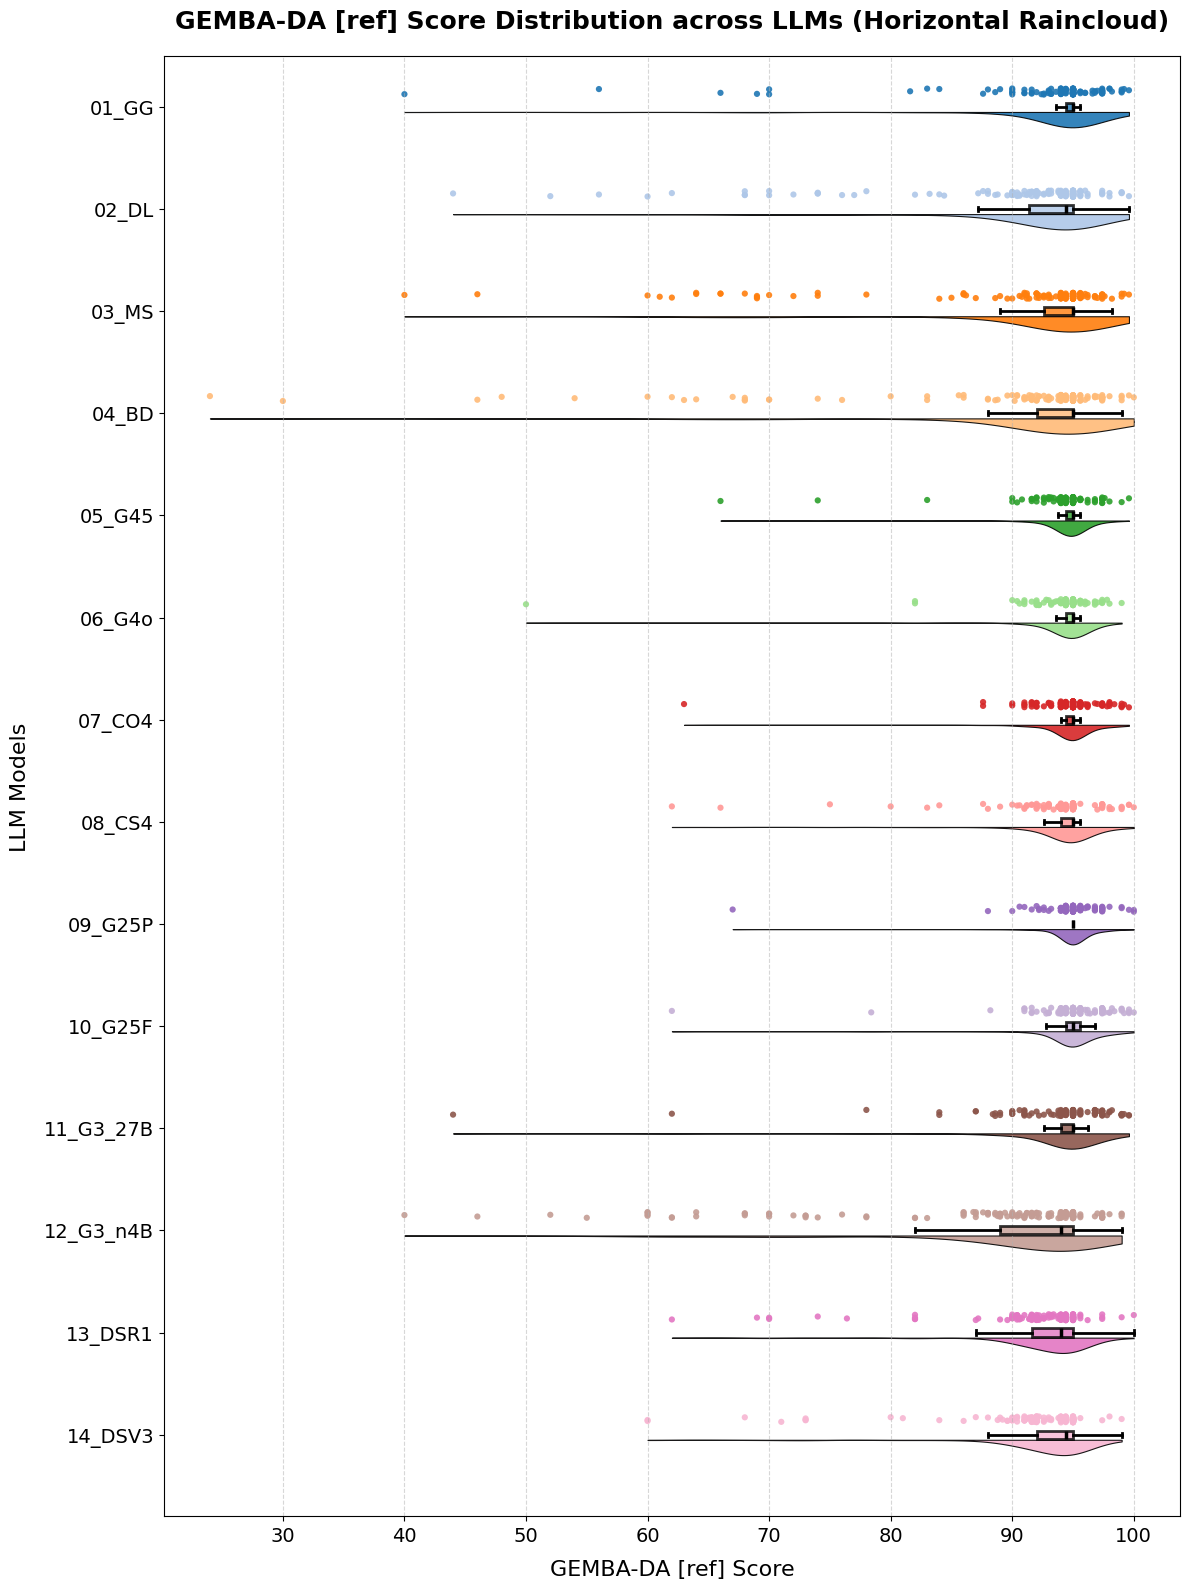

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 讀取您的 CSV 檔案
df = pd.read_csv("4_Repeated_ANOVA_DAREF_0714_OK.csv")

# 2. 寬格式轉長格式
model_cols = df.columns[1:]
df_long = pd.melt(df, id_vars=['Sentence_ID'], value_vars=model_cols, var_name='LLM_Model', value_name='Score')

# 確保 'Score' 欄位是數值型態，並處理非數值資料 (保留您優良的清洗步驟)
df_long['Score'] = pd.to_numeric(df_long['Score'], errors='coerce')
df_long.dropna(subset=['Score'], inplace=True)

# 3. 設定畫布尺寸為 A4 直式 (portrait)
# 標準 A4 大約是 8.27 x 11.69 英寸。為了容納 14 個模型，使用 (12, 16) 創造一個相對較高的畫布。
fig, ax = plt.subplots(figsize=(12, 16)) # 調整為 A4 直式比例，並放大

models = list(model_cols)
colors = sns.color_palette("tab20", len(models)) # 再次更換為 tab20 色板，提供更鮮明的顏色

# 4. 【核心修正】純手工精準定位：將圖表調整為水平方向
# 現在模型在 Y 軸，分數在 X 軸。元素的定位將繞 Y 軸模型中心線 `i` 進行調整。
for i, model in enumerate(models):
    # 篩選單一 LLM 模型的得分數據
    sub_data = df_long[df_long['LLM_Model'] == model]['Score'].values
    if len(sub_data) == 0:
        continue
    color = colors[i]

    # ─── 【上方】單邊雲朵：利用數學分佈手工畫出「單邊平滑核密度圖」 ───
    # 現在 KDE 是基於分數 (X 軸) 數據計算的
    kde = gaussian_kde(sub_data)
    score_range = np.linspace(sub_data.min(), sub_data.max(), 200) # X 軸是分數範圍
    density_values = kde(score_range) # 計算每個分數的密度
    density_values = (density_values / density_values.max()) * 0.15 # 標準化寬度，減少到 0.15 讓小提琴圖更細

    # 讓雲朵從基準點 i (Y 軸位置) 開始只往「上邊」長 (i 到 i + density_values)
    # 注意：這裡將小提琴圖的位置略微上移 (i + 0.05) 與箱型圖對齊，並確保與散點圖分離。
    ax.fill_between(score_range, i + 0.05, i + 0.05 + density_values, color=color, alpha=0.9, edgecolor='black', linewidth=0.8)

    # ─── 【中間偏下】細木箱：精準推移位置到 i，絕不與雨滴和雲朵疊死 ───
    # Boxplot 現在是水平的 (vert=False)，位置在 Y 軸 `i`，即每個模型的中心。
    ax.boxplot(sub_data, positions=[i], vert=False, widths=0.08, patch_artist=True,
               showfliers=False,
               boxprops=dict(facecolor=color, color='black', alpha=0.8, linewidth=2.0), # 加粗箱體線條
               medianprops=dict(color='black', linewidth=2.5), # 加粗中位數線條
               whiskerprops=dict(color='black', linewidth=2.0), # 加粗鬚線條
               capprops=dict(color='black', linewidth=2.0)) # 加粗帽線條

    # ─── 【下方】微型雨滴：精準偏移到下方 i - 0.15，並用極小點解決密集恐懼症 ───
    # 現在 jitter 是在 Y 軸方向應用，點的位置為 (分數, Y_jittered_位置)
    y_jitter = i - 0.15 + np.random.uniform(-0.03, 0.03, size=len(sub_data))
    ax.scatter(sub_data, y_jitter, color=color, alpha=0.9, s=20, edgecolor='none')

# 5. 調整標題、座標軸與字體
ax.set_title("GEMBA-DA [ref] Score Distribution across LLMs (Horizontal Raincloud)", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("GEMBA-DA [ref] Score", fontsize=16, labelpad=10) # X 軸是分數
ax.set_ylabel("LLM Models", fontsize=16, labelpad=10)     # Y 軸是模型

# 固定 Y 軸的標籤與位置，確保 14 個模型對齊得整整齊齊
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, rotation=0, ha='right', fontsize=14) # Y 軸標籤不需要旋轉，右對齊
ax.set_ylim(-0.5, len(models) - 0.2) # Y 軸範圍

# 根據 "由上而下01~14" 的要求反轉 Y 軸，使 01_GG 在最上方
ax.invert_yaxis()

plt.xticks(fontsize=14) # X 軸的刻度字體大小

# 加入淡灰色縱向虛線，方便口試時縱向對比各模型高低 (現在是縱向網格)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("LLM_Horizontal_Raincloud_With_Violin.png", dpi=300) # 匯出300dpi高解析度論文插圖
plt.show()